 # REGRESIÓN LINEAL MULTIPLE

## 1 - IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [ ]:
df = pd.read_csv('/content/insurance.csv')
#df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:

df = df.assign(sex=df["sex"].replace(["female", "male"], [0, 1]))
df = df.assign(smoker=df["smoker"].replace(["no", "yes"], [0, 1]))

df = pd.get_dummies(df, columns=["region"])



/tmp/ipykernel_443/4141302495.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.assign(sex=df["sex"].replace(["female", "male"], [0, 1]))
/tmp/ipykernel_443/4141302495.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.assign(smoker=df["smoker"].replace(["no", "yes"], [0, 1]))


In [ ]:
df.head(5)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [ ]:
df = df.assign(region_northeast=df["region_northeast"].replace([False, True], [0, 1]))
df = df.assign(region_northwest=df["region_northwest"].replace([False, True], [0, 1]))
df = df.assign(region_southeast=df["region_southeast"].replace([False, True], [0, 1]))
df = df.assign(region_southwest=df["region_southwest"].replace([False, True], [0, 1]))

/tmp/ipykernel_443/4264173887.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.assign(region_northeast=df["region_northeast"].replace([False, True], [0, 1]))
/tmp/ipykernel_443/4264173887.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.assign(region_northwest=df["region_northwest"].replace([False, True], [0, 1]))
/tmp/ipykernel_443/4264173887.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_

In [ ]:
df.head(5)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


## 3 - CORRELACIONES

In [ ]:
plt.rcParams['figure.figsize'] = (12, 8)

<Axes: >

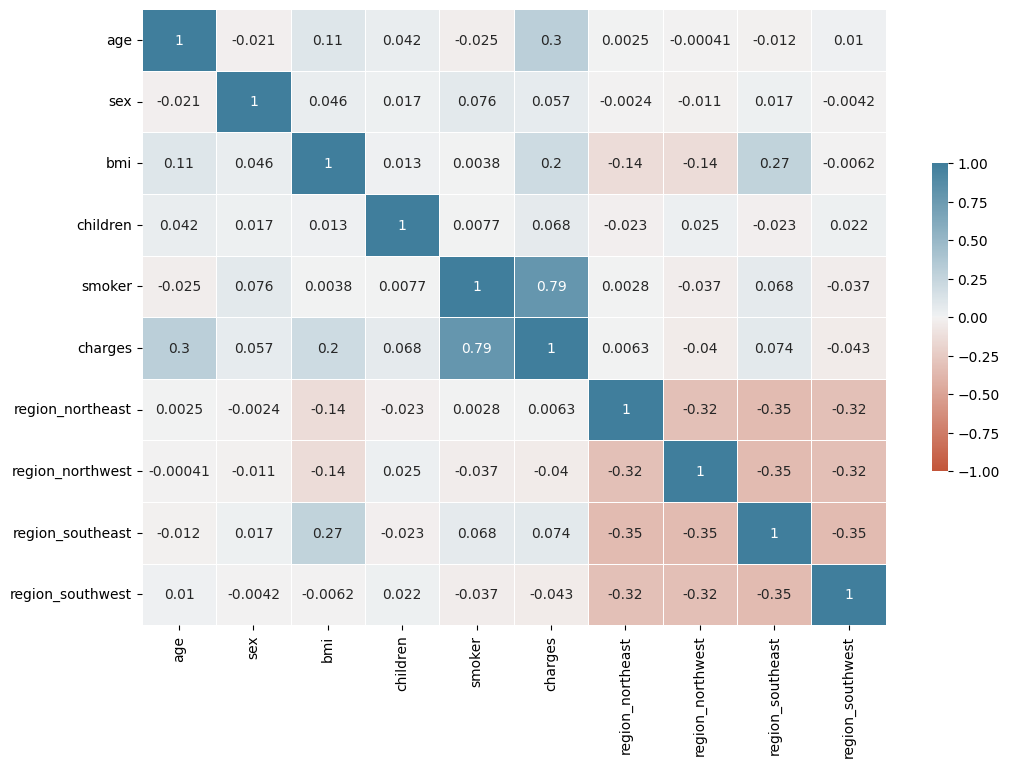

In [ ]:
sns.heatmap(
    data=df.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## 4 - CREAMOS UN MAPA DE CALOR DE LA VARIABLE DEPENDIENTE charges CONTRA TODAS LAS DEMAS

In [ ]:
corr_matrix = df.corr()
corr_medv = corr_matrix[['charges']].sort_values(by='charges',ascending=False)
corr_medv

,charges
charges,1.000000
smoker,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex,0.057292
region_northeast,0.006349
region_northwest,-0.039905
region_southwest,-0.043210


<Axes: >

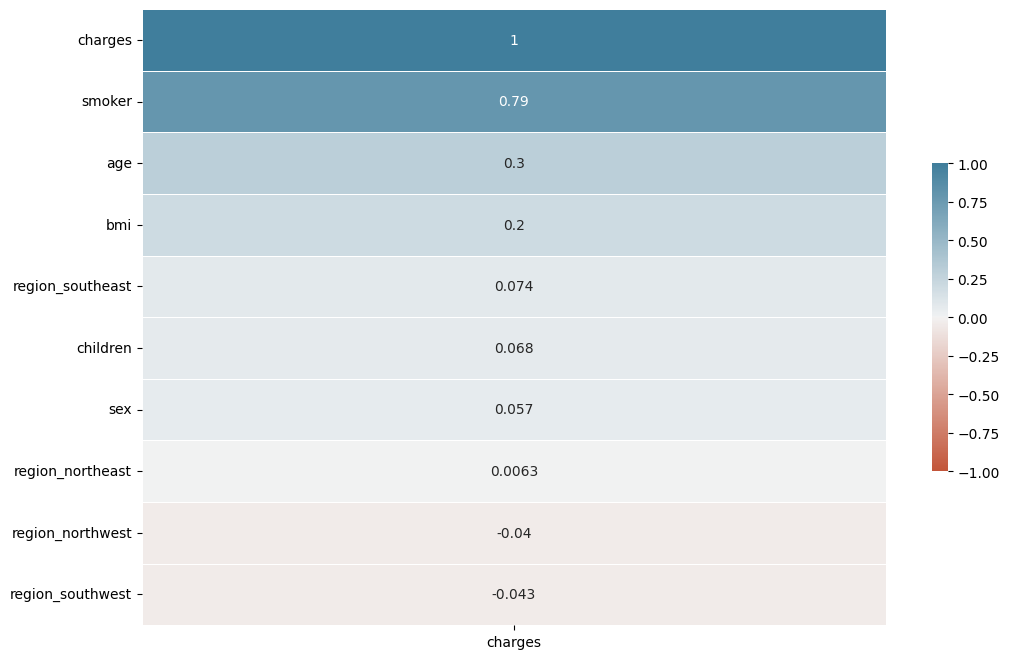

In [ ]:
sns.heatmap(
    data=corr_medv,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)

In [ ]:
cols = corr_medv.index.tolist()
cols.remove('charges')
cols

['smoker',
 'age',
 'bmi',
 'region_southeast',
 'children',
 'sex',
 'region_northeast',
 'region_northwest',
 'region_southwest']

## 5 - CREAMOS UN MODELO DE REGRESIÓN LINEAL SIMPLE PARA X = RM Y = MEDV

## 1 - DEFINIR VARIABLE X y Y

* X = RM(PROMEDIO DE HABITACIONES EN EL DEPARTAMENTO)
* Y = MEDV(VALOR PROMEDIO DEL DEPARTAMENTO)

In [37]:
X = df[cols].values
y = df['charges'].values.reshape(-1,1)

In [38]:
X

array([[ 1.  , 19.  , 27.9 , ...,  0.  ,  0.  ,  1.  ],
       [ 0.  , 18.  , 33.77, ...,  0.  ,  0.  ,  0.  ],
       [ 0.  , 28.  , 33.  , ...,  0.  ,  0.  ,  0.  ],
       ...,
       [ 0.  , 18.  , 36.85, ...,  0.  ,  0.  ,  0.  ],
       [ 0.  , 21.  , 25.8 , ...,  0.  ,  0.  ,  1.  ],
       [ 1.  , 61.  , 29.07, ...,  0.  ,  1.  ,  0.  ]])

In [39]:
y

array([[16884.924 ],
       [ 1725.5523],
       [ 4449.462 ],
       ...,
       [ 1629.8335],
       [ 2007.945 ],
       [29141.3603]])

## 1.1 DIVIDIR DATASET EN TRAIN Y TEST

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [41]:
print(f' X_train(valores de X para entrenamiento) : {X_train.shape[0]}')
print(f' y_train(valores de y para entrenamiento) : {y_train.shape[0]}')
print(f' X_test(valores de X para prueba) : {X_test.shape[0]}')
print(f' y_test(valores de y para prueba) : {y_test.shape[0]}')

 X_train(valores de X para entrenamiento) : 936
 y_train(valores de y para entrenamiento) : 936
 X_test(valores de X para prueba) : 402
 y_test(valores de y para prueba) : 402


# CALCULAMOS PROMEDIO Y STD

In [42]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 8.06326745014245
Desviación standard de X_train : 15.361243286005108


## 1.2 ESTANDARIZAMOS VALORES CON STANDARSCALER

In [43]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

In [44]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 1.6226336513752287e-16
Desviación standard de X_train : 1.0000000000000013


## 2 - IMPORTAR LIBREARIAS DE SKLEARN

In [45]:
from sklearn.linear_model import LinearRegression

## 3 - CREAMOS EL MODELO Y LO ENTRENAMOS CON LA DATA

In [46]:
slr = LinearRegression()
slr.fit(X_train,y_train)
y_pred = slr.predict(X_test)

## 4 - GRAFICAMOS LO REAL VS LOS PREDICHO

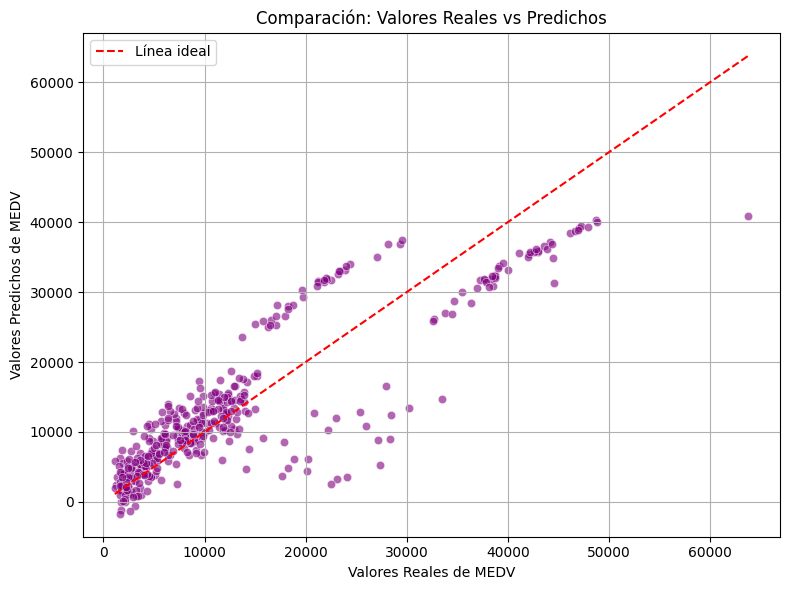

In [47]:
# Invertimos la escala para llevar y_test y y_pred a sus valores originales
y_test_real = sc_y.inverse_transform(y_test)
y_pred_real = sc_y.inverse_transform(y_pred)

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_real.flatten(), y=y_pred_real.flatten(), color='purple', alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         color='red', linestyle='--', label='Línea ideal')

plt.xlabel('Valores Reales de MEDV')
plt.ylabel('Valores Predichos de MEDV')
plt.title('Comparación: Valores Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6 - METRICAS DEL MODELO

In [48]:
import sklearn.metrics as metrics

# ERROR CUADRATICO MEDIO
mse = metrics.mean_squared_error(y_test,y_pred)
# R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.2306
El coeficiente de determinación(R2) es de 0.7696
